In [1]:
import os, sys, json, re, glob
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from tqdm.notebook import tqdm

In [2]:
!git clone -b KhangHy https://github.com/PhamQuocNam/CS338.git /kaggle/working/CS338
!pip install spikingjelly rwkv deepspeed ninja fissix tomli
!pip install -r "/kaggle/working/CS338/SpikeGPT/requirements.txt"
# Verify GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Cloning into '/kaggle/working/CS338'...
remote: Enumerating objects: 381, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 381 (delta 53), reused 83 (delta 36), pack-reused 275 (from 1)
Receiving objects: 100% (381/381), 46.98 MiB | 17.73 MiB/s, done.
Resolving deltas: 100% (137/137), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.4/411.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.5/188.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 3.9 MB/s eta 0:00:00
  Created wheel for deepspeed: filename=deepspeed-0.19.0-py3-none-any.whl size=1843042 sha256=6c8458f424d635b892c87ddb

In [3]:
SPIKEGPT_REPO_DIR = '/kaggle/working/CS338/SpikeGPT'

MODEL_PATH = '/kaggle/input/models/jakhanh1/spikegpt-agency-final/pytorch/default/1/Scratch220(best).pth'
DATA_PATH = '/kaggle/working/CS338/data/test_ood_data.jsonl'

HEAD_QK_DIM = 256
NUM_SAMPLES = 5000

OUTPUT_DIR = '/kaggle/working/eval_results'

model_name = os.path.basename(MODEL_PATH).replace('.pth', '')
run_dir = os.path.join(OUTPUT_DIR, f"{model_name}_HeadQK{HEAD_QK_DIM}")

if not os.path.exists(run_dir):
    os.makedirs(run_dir, exist_ok=True)
    print(f"Đã tạo thư mục: {run_dir}")
else:
    print(f"Thư mục đã tồn tại: {run_dir}")


Đã tạo thư mục: /kaggle/working/eval_results/Scratch220(best)_HeadQK256


In [4]:
import os
os.chdir(SPIKEGPT_REPO_DIR)
print(f"Current working directory: {os.getcwd()}")

Current working directory: /kaggle/working/CS338/SpikeGPT


In [5]:
# Set tham số môi trường TRƯỚC khi import model
os.environ["RWKV_HEAD_QK_DIM"] = str(HEAD_QK_DIM)
os.environ["RWKV_JIT_ON"] = '1'
os.environ["RWKV_RUN_DEVICE"] = "cuda"

if SPIKEGPT_REPO_DIR not in sys.path:
    sys.path.append(SPIKEGPT_REPO_DIR)

from src.model import GPT, GPTConfig
from src.utils import TOKENIZER

# Khởi tạo mô hình
vocab_size = 50277
ctx_len = 1024
config = GPTConfig(vocab_size=vocab_size, ctx_len=ctx_len, model_type='RWKV', n_layer=18, n_embd=768)
model = GPT(config)

if os.path.exists(MODEL_PATH):
    w = torch.load(MODEL_PATH, map_location='cpu')
    load_result = model.load_state_dict(w, strict=False)
    print(f"Đã nạp tạ. Missing keys: {load_result.missing_keys}")
else:
    print(f"Lỗi: Không tìm thấy {MODEL_PATH}")

model = model.cuda()
model.eval()

# Khởi tạo Tokenizer
tokenizer_path = os.path.join(SPIKEGPT_REPO_DIR, "20B_tokenizer.json")
if not os.path.exists(tokenizer_path):
    # Fallback nếu đường dẫn hiện tại
    tokenizer_path = "20B_tokenizer.json"
tokenizer = TOKENIZER([tokenizer_path, tokenizer_path], UNKNOWN_CHAR=None)

def parse_dataset(filepath, num_samples=None):
    samples = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip(): continue
            data = json.loads(line)
            text = data['text']
            user_match = re.search(r"<\|im_start\|>user\n(.*?)<\|im_end\|>", text, re.DOTALL)
            user_prompt = user_match.group(1).strip() if user_match else ""
            gt_match = re.search(r"<tool_call>\n(.*?)\n</tool_call>", text, re.DOTALL)
            gt_json_str = gt_match.group(1).strip() if gt_match else "{}"
            try:
                gt_json = json.loads(gt_json_str)
            except:
                gt_json = {}
            if user_prompt and gt_json:
                samples.append({"prompt": user_prompt, "gt_name": gt_json.get("name", "unknown"), "gt_args": gt_json.get("arguments", {})})
            if num_samples and len(samples) >= num_samples:
                break
    return samples

def generate_text(model, tokenizer, prompt, max_new_tokens=150, ctx_len=1024):
    ctx = tokenizer.tokenizer.encode(prompt)
    src_len = len(ctx)
    for j in range(src_len):
        x = ctx[: j + 1]
        if j == src_len - 1:
            out = model.forward(torch.tensor([x], dtype=torch.long).cuda())
    out_tokens = []
    for k in range(src_len, src_len + max_new_tokens):
        x = ctx[: k + 1]
        x = x[-ctx_len:]
        out = model.forward(torch.tensor([x], dtype=torch.long).cuda())
        logits = out[0, -1]
        token = torch.argmax(logits).item()
        if token == 0: break
        out_tokens.append(token)
        ctx.append(token)
        if "</tool_call>" in tokenizer.tokenizer.decode(out_tokens):
            break
    return tokenizer.tokenizer.decode(out_tokens)

def extract_json_from_output(output_text):
    match = re.search(r"<tool_call>\n?(.*?)\n?</tool_call>", output_text, re.DOTALL)
    if not match:
        match = re.search(r"(\{.*?\})", output_text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1).strip()), True
        except:
            return {"name": "invalid_json", "arguments": {}}, False
    return {"name": "no_json_found", "arguments": {}}, False

/kaggle/working/CS338/SpikeGPT/src/spikingjelly/clock_driven/surrogate.py:888: SyntaxWarning: invalid escape sequence '\p'
  g'(x) = \\frac{\\alpha}{\\sqrt{\pi}}e^{-\\alpha^2x^2}
/kaggle/working/CS338/SpikeGPT/src/spikingjelly/clock_driven/surrogate.py:1291: SyntaxWarning: invalid escape sequence '\g'
  \\beta (x + 1), x \ge 0
2026-05-11 09:37:47.101190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778492267.338760      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778492267.403180      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778492267.930198      23 computation_placer.cc:177] computation placer already registered. Plea


RWKV_HEAD_QK_DIM 256

[1/3] /usr/local/cuda/bin/nvcc --generate-dependencies-with-compile --dependency-output wkv_cuda.cuda.o.d -DTORCH_EXTENSION_NAME=wkv -DTORCH_API_INCLUDE_EXTENSION_H -isystem /usr/local/lib/python3.12/dist-packages/torch/include -isystem /usr/local/lib/python3.12/dist-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda/include -isystem /usr/include/python3.12 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS__ --expt-relaxed-constexpr -gencode=arch=compute_75,code=compute_75 -gencode=arch=compute_75,code=sm_75 --compiler-options '-fPIC' -res-usage --maxrregcount 60 --use_fast_math -O3 -Xptxas -O3 -DTmax=1024 -std=c++17 -c /kaggle/working/CS338/SpikeGPT/cuda/wkv_cuda.cu -o wkv_cuda.cuda.o 
ptxas info    : Overriding maximum register limit 256 for '_Z15kernel_backwardIfEviiiPKT_S2_S2_S2_S2_PS0_S3_S3_S3_' with  60 of maxrregcount option
ptxas info    : Overriding maximum regis

In [6]:
samples = parse_dataset(DATA_PATH, num_samples=NUM_SAMPLES)
print(f"Tổng số mẫu test: {len(samples)}")

y_true_intent = []
y_pred_intent = []
metrics = {"valid_json_count": 0, "exact_args_match": 0}
results_log = []

print("Đang chạy suy luận...")
for i, sample in enumerate(tqdm(samples)):
    prompt = f"<|im_start|>system\nHãy thực hiện theo yêu cầu<|im_end|>\n<|im_start|>user\n{sample['prompt']}<|im_end|>\n<|im_start|>assistant\n"
    with torch.no_grad():
        output_text = generate_text(model, tokenizer, prompt)

    pred_json, is_valid = extract_json_from_output(output_text)

    gt_name = sample['gt_name']
    pred_name = pred_json.get("name", "unknown")

    y_true_intent.append(gt_name)
    y_pred_intent.append(pred_name)

    if is_valid: metrics["valid_json_count"] += 1

    gt_args = sample['gt_args']
    pred_args = pred_json.get("arguments", {})
    is_args_exact = (gt_args == pred_args)
    if is_args_exact: metrics["exact_args_match"] += 1

    results_log.append({
        "prompt": sample['prompt'],
        "ground_truth": {"name": gt_name, "arguments": gt_args},
        "prediction": {"name": pred_name, "arguments": pred_args},
        "raw_output": output_text,
        "is_valid_json": is_valid,
        "is_args_exact": is_args_exact
    })

# Lưu Log để xem lại các câu sai
with open(os.path.join(run_dir, "predictions.json"), "w", encoding="utf-8") as f:
    json.dump(results_log, f, ensure_ascii=False, indent=2)
print("Đã lưu lịch sử suy luận.")

Tổng số mẫu test: 5000
Đang chạy suy luận...


  0%|          | 0/5000 [00:00<?, ?it/s]

Đã lưu lịch sử suy luận.


In [7]:
valid_json_rate = metrics["valid_json_count"] / len(samples)
args_exact_rate = metrics["exact_args_match"] / len(samples)
intent_acc = accuracy_score(y_true_intent, y_pred_intent)
precision, recall, f1, _ = precision_recall_fscore_support(y_true_intent, y_pred_intent, average='weighted', zero_division=0)
report = classification_report(y_true_intent, y_pred_intent, zero_division=0)

report_text = f"=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH: {model_name} ===\n"
report_text += f"Cấu hình HeadQK: {HEAD_QK_DIM}\n"
report_text += "-"*40 + "\n"
report_text += f"1. Sinh JSON hợp lệ (Valid JSON) : {valid_json_rate:.2%}\n"
report_text += f"2. Chọn đúng Tool (Intent Acc)   : {intent_acc:.2%}\n"
report_text += f"3. Copy đúng ID (Args Exact Match): {args_exact_rate:.2%}\n"
report_text += "-"*40 + "\n"
report_text += f"Precision (Weighted): {precision:.4f}\n"
report_text += f"Recall (Weighted)   : {recall:.4f}\n"
report_text += f"F1 Score (Weighted) : {f1:.4f}\n"
report_text += "-"*40 + "\n"
report_text += "CHI TIẾT PHÂN LOẠI TOOL:\n" + report

with open(os.path.join(run_dir, "metrics_report.txt"), "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)

=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH: Scratch220(best) ===
Cấu hình HeadQK: 256
----------------------------------------
1. Sinh JSON hợp lệ (Valid JSON) : 91.52%
2. Chọn đúng Tool (Intent Acc)   : 81.24%
3. Copy đúng ID (Args Exact Match): 4.68%
----------------------------------------
Precision (Weighted): 0.9022
Recall (Weighted)   : 0.8124
F1 Score (Weighted) : 0.8463
----------------------------------------
CHI TIẾT PHÂN LOẠI TOOL:
                  precision    recall  f1-score   support

 check_inventory       0.97      0.81      0.88       877
    create_order       0.89      0.77      0.83       832
    delete_order       0.95      0.84      0.89       840
       get_order       0.73      0.84      0.78       810
    invalid_json       0.00      0.00      0.00         0
   no_json_found       0.00      0.00      0.00         0
revenue_analysis       0.87      1.00      0.93       789
    update_order       1.00      0.63      0.77       852

        accuracy                           

/tmp/ipykernel_23/3926473140.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_names, y=metrics_values, palette="viridis")


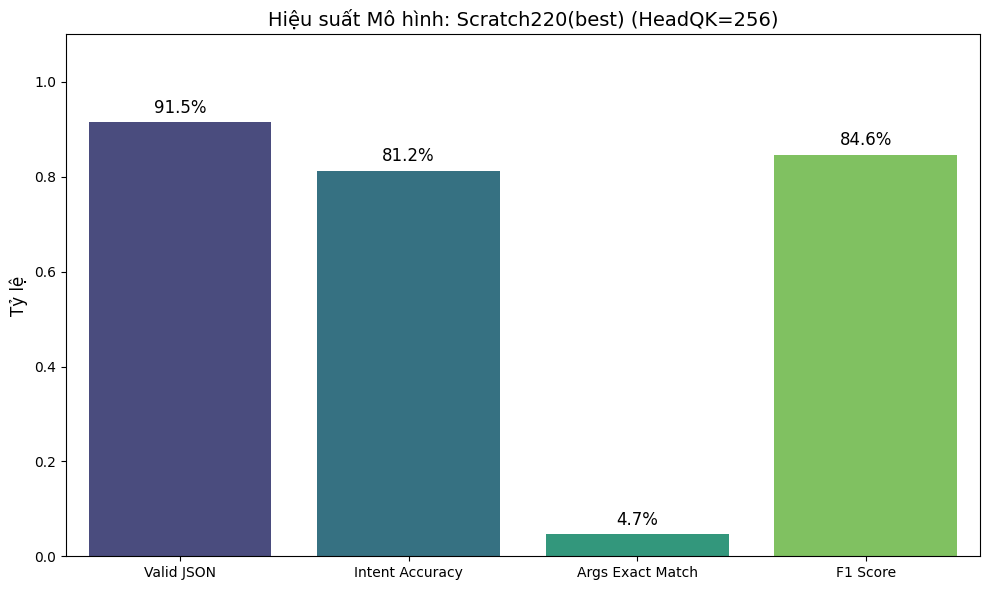

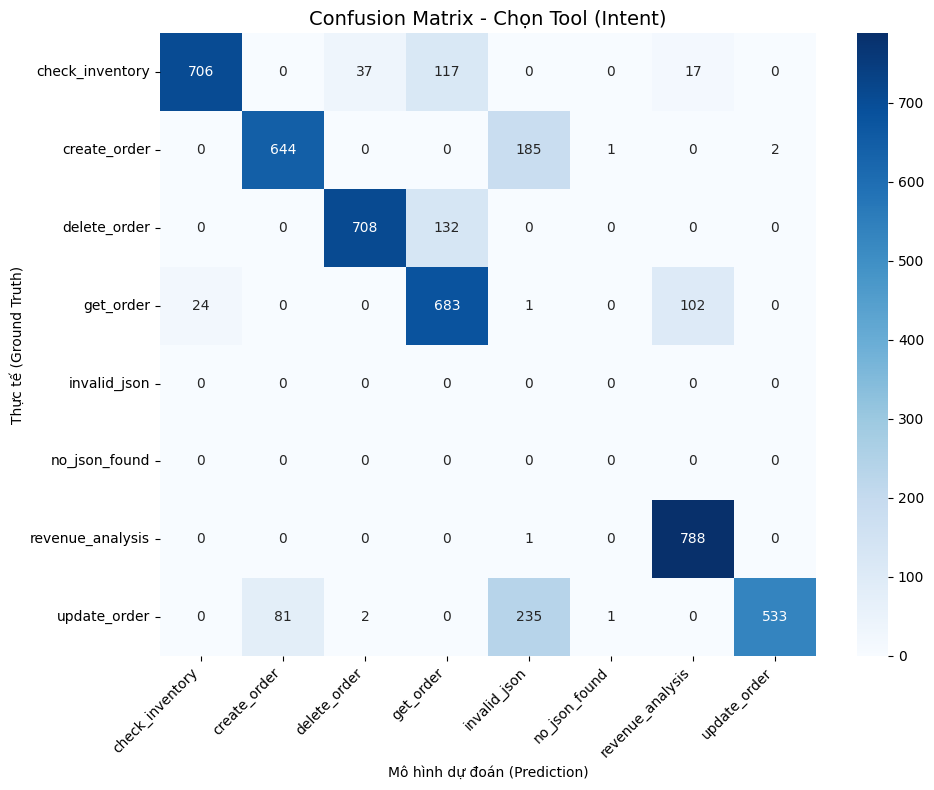


Đánh giá hoàn tất! File Report và Biểu đồ đã được lưu vào thư mục: /kaggle/working/eval_results/Scratch220(best)_HeadQK256/


In [8]:
# 1. Bar Chart Tổng quan
metrics_names = ['Valid JSON', 'Intent Accuracy', 'Args Exact Match', 'F1 Score']
metrics_values = [valid_json_rate, intent_acc, args_exact_rate, f1]

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_names, y=metrics_values, palette="viridis")
plt.ylim(0, 1.1)
plt.title(f"Hiệu suất Mô hình: {model_name} (HeadQK={HEAD_QK_DIM})", fontsize=14)
for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center', fontsize=12)
plt.ylabel('Tỷ lệ', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(run_dir, "overall_performance.png"), dpi=300)
plt.show()

# 2. Confusion Matrix
labels = sorted(list(set(y_true_intent + y_pred_intent)))
cm = confusion_matrix(y_true_intent, y_pred_intent, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Chọn Tool (Intent)", fontsize=14)
plt.ylabel("Thực tế (Ground Truth)")
plt.xlabel("Mô hình dự đoán (Prediction)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(run_dir, "intent_confusion_matrix.png"), dpi=300)
plt.show()

print(f"\nĐánh giá hoàn tất! File Report và Biểu đồ đã được lưu vào thư mục: {run_dir}/")